# Airline Loyalty Program Analysis
## Churn Prediction, Customer Segmentation & Smart Retention

> **Dataset:** ~16,700 Canadian loyalty members (2012-2018)  
> **Objectives:** (1) Predict churn proactively, (2) Segment customers by value drivers, (3) Design targeted retention interventions

---
## Table of Contents
1. [Environment Setup](#1)
2. [Data Loading](#2)
3. [Data Quality & Cleaning](#3)
4. [Exploratory Data Analysis](#4)
5. [Churn Definition & Feature Engineering](#5)
6. [Churn Prediction Models](#6)
7. [Customer Segmentation](#7)
8. [Smart Retention Strategy](#8)
9. [Summary](#9)

---
<a id='1'></a>
## 1. Environment Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})
#DATA_DIR = '/mnt/user-data/uploads/'
print('Libraries loaded.')

Libraries loaded.


---
<a id='2'></a>
## 2. Data Loading & Initial Inspection

In [ ]:
loyalty_hist = pd.read_csv('/content/Customer Loyalty History.csv')
flight_act   = pd.read_csv('/content/Customer Flight Activity.csv')
calendar     = pd.read_csv('/content/Calendar.csv',
                           parse_dates=['Date','Start of Year',
                                        'Start of Quarter','Start of Month'])
data_dict    = pd.read_csv('/content/Airline Loyalty Data Dictionary.csv')

for name, df in [('Loyalty History', loyalty_hist),
                 ('Flight Activity', flight_act),
                 ('Calendar', calendar)]:
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} cols')

Loyalty History: 16,737 rows x 16 cols
Flight Activity: 392,936 rows x 8 cols
Calendar: 2,557 rows x 4 cols


In [ ]:
# Enrich calendar with Season and Quarter
calendar['Quarter'] = calendar['Start of Quarter'].dt.quarter
calendar['Season']  = calendar['Start of Quarter'].dt.month.map(
    {1: 'Winter', 4: 'Spring', 7: 'Summer', 10: 'Fall'})
calendar['Year']  = calendar['Date'].dt.year
calendar['Month'] = calendar['Date'].dt.month

cal_lookup = (calendar
              .groupby(['Year','Month'])
              .agg(Quarter=('Quarter','first'), Season=('Season','first'))
              .reset_index())
print(f'Calendar: {calendar["Date"].min().date()} to {calendar["Date"].max().date()}')
loyalty_hist.head()

Calendar: 2012-01-01 to 2018-12-31


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [ ]:
flight_act.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


---
<a id='3'></a>
## 3. Data Quality Assessment & Cleaning

### 3.1 Missing Value Analysis

In [ ]:
def missing_summary(df, label):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    res  = pd.DataFrame({'Missing Count': miss, 'Missing %': pct})
    res  = res[res['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'--- {label} ---')
    if res.empty:
        print('  No missing values.')
    else:
        display(res)
    print()

missing_summary(loyalty_hist, 'Customer Loyalty History')
missing_summary(flight_act,   'Customer Flight Activity')

--- Customer Loyalty History ---


,Missing Count,Missing %
Cancellation Year,14670,87.65
Cancellation Month,14670,87.65
Salary,4238,25.32



--- Customer Flight Activity ---
  No missing values.



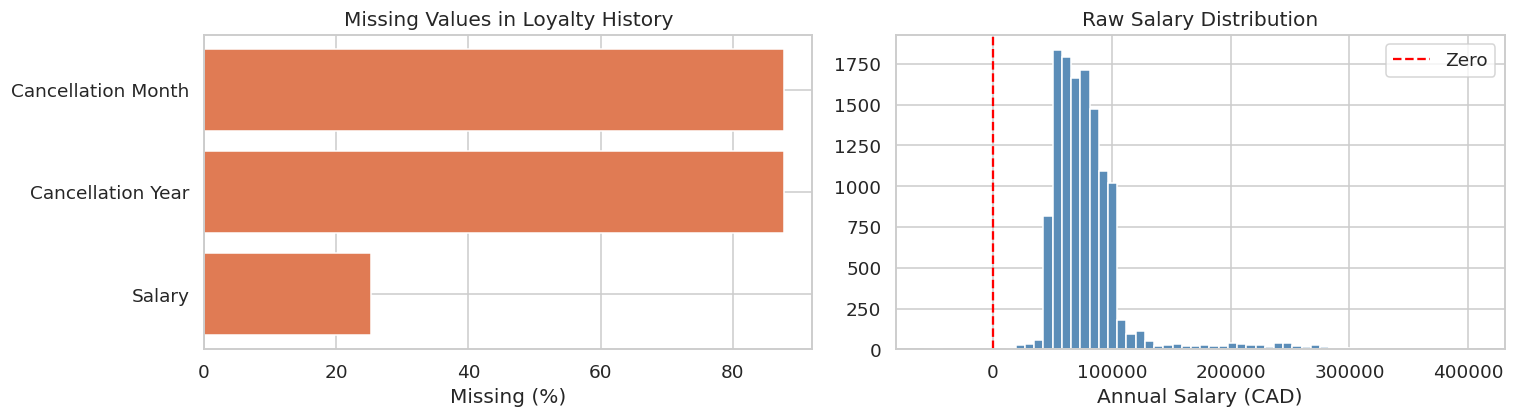

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

miss_pct = loyalty_hist.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0]
axes[0].barh(miss_pct.index, miss_pct.values, color='#e07b54')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values in Loyalty History')

axes[1].hist(loyalty_hist['Salary'].dropna(), bins=60,
             color='#5b8db8', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Zero')
axes[1].set_xlabel('Annual Salary (CAD)')
axes[1].set_title('Raw Salary Distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

### 3.2 Data Quality Issues & Cleaning Decisions

| Issue | Column | Decision |
|---|---|---|
| Negative salary (n=20) | `Salary` | Set to NaN (erroneous) |
| Missing salary (n=4,238, 25.3%) | `Salary` | Median impute per card tier |
| Cancellation columns not-null | Both cancellation cols | Source of hard-churn label |
| Flight data covers 2017-2018 only | `Year` | Behaviour features scoped accordingly |
| Zero-flight monthly rows (54.5%) | `Total Flights` | Retained as churn signal |

In [ ]:
lh = loyalty_hist.copy()

# Fix negative salaries
neg_mask = lh['Salary'] < 0
print(f'Negative salary records: {neg_mask.sum()}')
lh.loc[neg_mask, 'Salary'] = np.nan

# Impute missing salary (median per card tier)
lh['Salary'] = lh.groupby('Loyalty Card')['Salary'].transform(
    lambda x: x.fillna(x.median()))
lh['Salary'].fillna(lh['Salary'].median(), inplace=True)
print(f'Missing salary after imputation: {lh["Salary"].isna().sum()}')

# Hard churn flag
lh['formal_churn'] = lh['Cancellation Year'].notna().astype(int)
print(f'Formal churn rate: {lh["formal_churn"].mean()*100:.1f}%')

# Encode ordinals
edu_order  = {'High School or Below':0,'College':1,'Bachelor':2,'Master':3,'Doctor':4}
card_order = {'Star':0,'Nova':1,'Aurora':2}
lh['Education_ord'] = lh['Education'].map(edu_order)
lh['Card_ord']      = lh['Loyalty Card'].map(card_order)

# One-hot encode nominals
lh = pd.get_dummies(lh, columns=['Gender','Marital Status'], drop_first=True)
lh.head(3)

Negative salary records: 20
Missing salary after imputation: 0
Formal churn rate: 12.3%


,Loyalty Number,Country,Province,City,Postal Code,Education,Salary,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,formal_churn,Education_ord,Card_ord,Gender_Male,Marital Status_Married,Marital Status_Single
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Bachelor,83236.0,Star,3839.14,Standard,2016,2,NaN,NaN,0,2,0,False,True,False
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,College,73136.0,Star,3839.61,Standard,2016,3,NaN,NaN,0,1,0,True,False,False
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,College,73136.0,Star,3839.75,Standard,2014,7,2018.0,1.0,1,1,0,True,False,True


In [ ]:
# Clean flight activity
fa = flight_act.copy()
fa = fa.merge(cal_lookup, on=['Year','Month'], how='left')
print('Year range:', fa['Year'].min(), '-', fa['Year'].max())
print(f'Zero-flight rows: {(fa["Total Flights"]==0).mean()*100:.1f}%')
fa.describe()

Year range: 2017 - 2018
Zero-flight rows: 54.5%


,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Quarter
count,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000
mean,550527.519034,2017.513661,6.513661,1.294888,1941.440201,2027.172345,31.304263,5.635661,2.503726
std,258604.580187,0.499814,3.445428,1.962675,3239.975889,3872.139841,126.653775,22.801167,1.116918
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,327688.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,551833.000000,2018.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,772194.000000,2018.000000,10.000000,2.000000,3018.000000,3039.000000,0.000000,0.000000,4.000000
max,999986.000000,2018.000000,12.000000,28.000000,67284.000000,100926.000000,876.000000,158.000000,4.000000


---
<a id='4'></a>
## 4. Exploratory Data Analysis

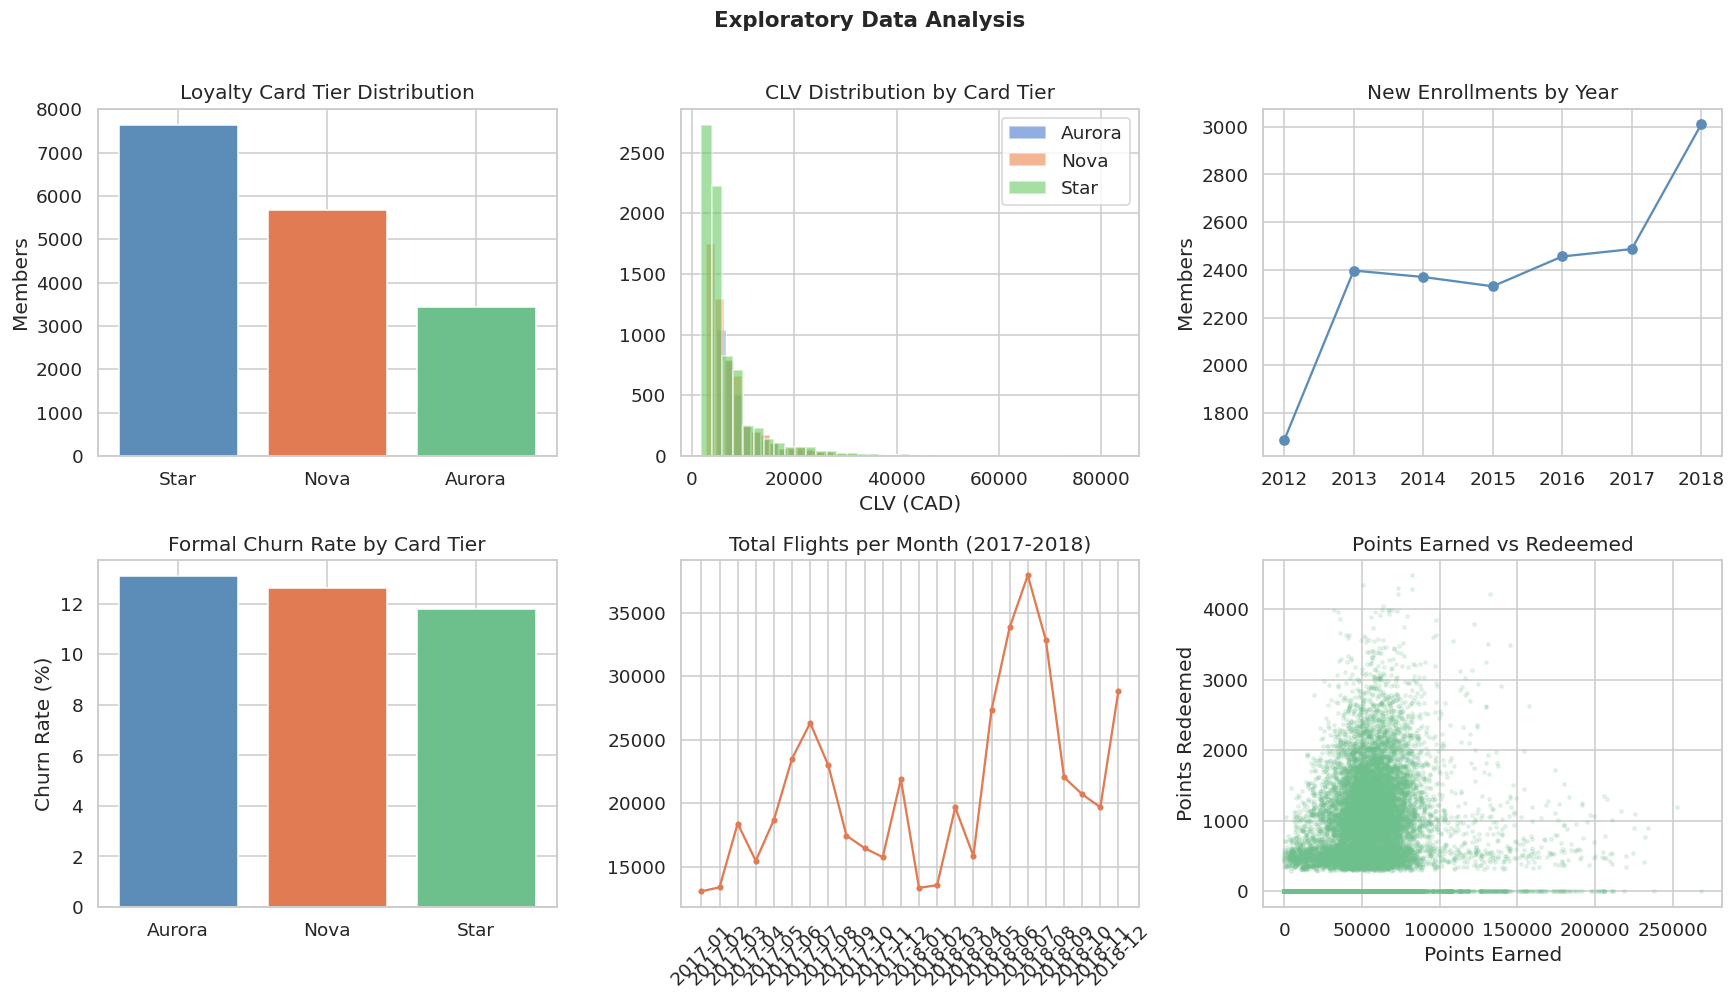

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Card tier distribution
card_counts = lh['Loyalty Card'].value_counts()
axes[0,0].bar(card_counts.index, card_counts.values,
              color=['#5b8db8','#e07b54','#6dbf8b'])
axes[0,0].set_title('Loyalty Card Tier Distribution')
axes[0,0].set_ylabel('Members')

# CLV distribution by card tier
for tier, grp in lh.groupby('Loyalty Card'):
    axes[0,1].hist(grp['CLV'], bins=40, alpha=0.6, label=tier)
axes[0,1].set_xlabel('CLV (CAD)')
axes[0,1].set_title('CLV Distribution by Card Tier')
axes[0,1].legend()

# Enrollment trend
enroll = lh.groupby('Enrollment Year').size()
axes[0,2].plot(enroll.index, enroll.values, marker='o', color='#5b8db8')
axes[0,2].set_title('New Enrollments by Year')
axes[0,2].set_ylabel('Members')

# Formal churn rate by card tier
churn_by_card = lh.groupby('Loyalty Card')['formal_churn'].mean() * 100
axes[1,0].bar(churn_by_card.index, churn_by_card.values,
              color=['#5b8db8','#e07b54','#6dbf8b'])
axes[1,0].set_title('Formal Churn Rate by Card Tier')
axes[1,0].set_ylabel('Churn Rate (%)')

# Monthly flight volume
monthly = (fa[fa['Total Flights']>0]
           .groupby(['Year','Month'])['Total Flights'].sum().reset_index())
monthly['period'] = (monthly['Year'].astype(str)+'-'
                     +monthly['Month'].astype(str).str.zfill(2))
axes[1,1].plot(monthly['period'], monthly['Total Flights'],
               color='#e07b54', marker='.')
axes[1,1].set_title('Total Flights per Month (2017-2018)')
axes[1,1].tick_params(axis='x', rotation=45)

# Points earned vs redeemed
agg_pts = fa.groupby('Loyalty Number').agg(
    earned=('Points Accumulated','sum'),
    redeemed=('Points Redeemed','sum')).reset_index()
axes[1,2].scatter(agg_pts['earned'], agg_pts['redeemed'],
                  alpha=0.15, s=5, color='#6dbf8b')
axes[1,2].set_xlabel('Points Earned')
axes[1,2].set_ylabel('Points Redeemed')
axes[1,2].set_title('Points Earned vs Redeemed')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

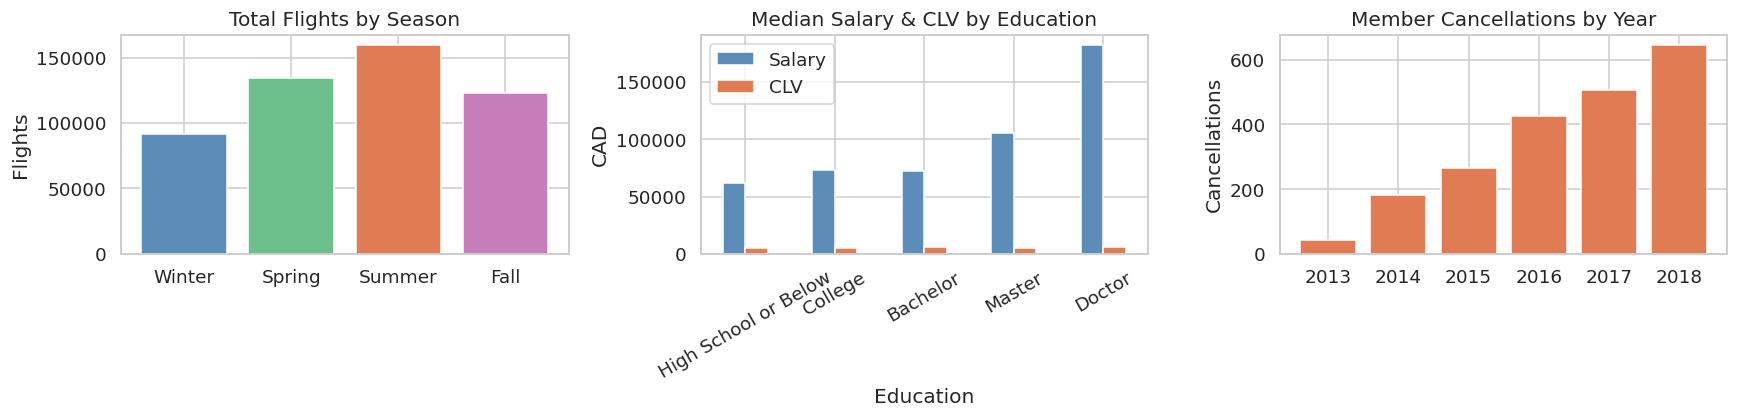

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Seasonal flights
seasonal = fa.groupby('Season')['Total Flights'].sum().reindex(
    ['Winter','Spring','Summer','Fall'])
axes[0].bar(seasonal.index, seasonal.values,
            color=['#5b8db8','#6dbf8b','#e07b54','#c77dba'])
axes[0].set_title('Total Flights by Season')
axes[0].set_ylabel('Flights')

# Education vs CLV
edu_order_list = ['High School or Below','College','Bachelor','Master','Doctor']
edu_clv = lh.groupby('Education')[['Salary','CLV']].median().reindex(edu_order_list)
edu_clv.plot(kind='bar', ax=axes[1], color=['#5b8db8','#e07b54'])
axes[1].set_title('Median Salary & CLV by Education')
axes[1].set_ylabel('CAD')
axes[1].tick_params(axis='x', rotation=30)

# Cancellations by year
cancel_yr = lh[lh['formal_churn']==1].groupby('Cancellation Year').size()
axes[2].bar(cancel_yr.index.astype(int), cancel_yr.values,
            color='#e07b54', edgecolor='white')
axes[2].set_title('Member Cancellations by Year')
axes[2].set_ylabel('Cancellations')

plt.tight_layout(); plt.show()

---
<a id='5'></a>
## 5. Churn Definition & Feature Engineering

### 5.1 Churn Definition

We define two complementary churn signals to avoid undercounting silent disengagement:

| Signal | Definition | Rationale |
|---|---|---|
| **Hard churn** | `Cancellation Year/Month` not null | Explicit programme cancellation |
| **Soft churn** | Zero flights Jul-Dec 2018 AND enrolled >= 12 months | Disengaged but not formally cancelled |
| **Composite label** | Hard OR Soft | Captures both overt and silent churn |

**Leakage prevention:**
- Observation window (features): Jan-Jun 2018
- Outcome window (label): Jul-Dec 2018
- Historical window (trends): Full year 2017
- Cancellation columns are used ONLY for label construction, never as features

In [ ]:
OBS_YEAR, OBS_START, OBS_END = 2018, 1, 6
OUT_YEAR, OUT_START, OUT_END = 2018, 7, 12

fa_obs  = fa[(fa['Year']==OBS_YEAR) & fa['Month'].between(OBS_START, OBS_END)]
fa_out  = fa[(fa['Year']==OUT_YEAR) & fa['Month'].between(OUT_START, OUT_END)]
fa_hist = fa[fa['Year']==2017]

print(f'Observation window (features): {len(fa_obs):,} rows')
print(f'Outcome window     (label):    {len(fa_out):,} rows')
print(f'Historical window  (trends):   {len(fa_hist):,} rows')

Observation window (features): 100,430 rows
Outcome window     (label):    101,406 rows
Historical window  (trends):   191,100 rows


In [ ]:
# Soft churn: no flights in outcome window
flights_outcome = (fa_out.groupby('Loyalty Number')['Total Flights']
                   .sum().reset_index()
                   .rename(columns={'Total Flights':'outcome_flights'}))

keep_cols = ['Loyalty Number','formal_churn','Enrollment Year','Enrollment Month',
             'Cancellation Year','Cancellation Month',
             'CLV','Loyalty Card','Card_ord','Education','Education_ord',
             'Salary','Province','Gender_Male','Enrollment Type']

for col in ['Marital Status_Married','Marital Status_Single']:
    if col in lh.columns:
        keep_cols.append(col)

churn_df = lh[keep_cols].copy()
churn_df = churn_df.merge(flights_outcome, on='Loyalty Number', how='left')
churn_df['outcome_flights'] = churn_df['outcome_flights'].fillna(0)

# Enrolled at least 12 months before outcome window
churn_df['enroll_date'] = pd.to_datetime(
    churn_df['Enrollment Year'].astype(str)+'-'
    +churn_df['Enrollment Month'].astype(str).str.zfill(2)+'-01')
churn_df['enrolled_ok'] = (churn_df['enroll_date'] <= pd.Timestamp('2017-07-01')).astype(int)

churn_df['soft_churn'] = (
    (churn_df['outcome_flights']==0) &
    (churn_df['enrolled_ok']==1) &
    (churn_df['formal_churn']==0)
).astype(int)

churn_df['churn'] = (
    (churn_df['formal_churn']==1) | (churn_df['soft_churn']==1)
).astype(int)

print('=== Churn Label Summary ===')
print(f'Hard churn: {churn_df["formal_churn"].sum():,} ({churn_df["formal_churn"].mean()*100:.1f}%)')
print(f'Soft churn: {churn_df["soft_churn"].sum():,} ({churn_df["soft_churn"].mean()*100:.1f}%)')
print(f'Composite:  {churn_df["churn"].sum():,} ({churn_df["churn"].mean()*100:.1f}%)')

=== Churn Label Summary ===
Hard churn: 2,067 (12.3%)
Soft churn: 328 (2.0%)
Composite:  2,395 (14.3%)


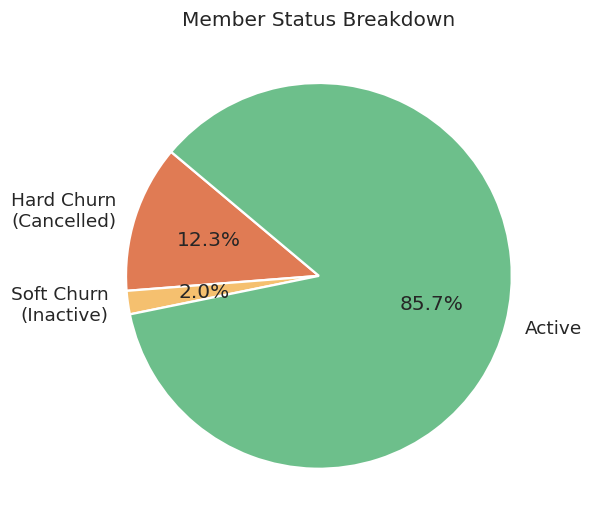

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
labels = ['Hard Churn\n(Cancelled)', 'Soft Churn\n(Inactive)', 'Active']
sizes  = [churn_df['formal_churn'].sum(), churn_df['soft_churn'].sum(),
          len(churn_df)-churn_df['churn'].sum()]
ax.pie(sizes, labels=labels, colors=['#e07b54','#f5c06f','#6dbf8b'],
       autopct='%1.1f%%', startangle=140,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Member Status Breakdown')
plt.tight_layout(); plt.show()

### 5.2 Feature Engineering

In [ ]:
def agg_window(df_w, suffix):
    agg = df_w.groupby('Loyalty Number').agg(
        flights        = ('Total Flights','sum'),
        distance       = ('Distance','sum'),
        pts_earned     = ('Points Accumulated','sum'),
        pts_redeem     = ('Points Redeemed','sum'),
        active_months  = ('Total Flights', lambda x: (x>0).sum()),
        avg_flights_pm = ('Total Flights','mean'),
        max_flights    = ('Total Flights','max'),
    ).reset_index()
    agg.columns = ['Loyalty Number'] + [f'{c}_{suffix}' for c in agg.columns[1:]]
    return agg

obs_feats  = agg_window(fa_obs, 'obs')
hist_feats = agg_window(fa_hist,'hist')

# Redemption ratio
obs_feats['redemption_ratio_obs'] = (
    obs_feats['pts_redeem_obs'] / (obs_feats['pts_earned_obs']+1))

# Recency: months since last active flight in observation window
last_fl = (fa[(fa['Year']==OBS_YEAR) & (fa['Month']<=OBS_END) & (fa['Total Flights']>0)]
           .groupby('Loyalty Number')['Month'].max()
           .reset_index().rename(columns={'Month':'last_month'}))
last_fl['recency_months'] = OBS_END - last_fl['last_month']

# Flight trend: H1-2018 avg vs 2017 avg
trend = obs_feats[['Loyalty Number','avg_flights_pm_obs']].merge(
    hist_feats[['Loyalty Number','avg_flights_pm_hist']],
    on='Loyalty Number', how='outer')
trend['flight_trend'] = trend['avg_flights_pm_obs'].fillna(0) - trend['avg_flights_pm_hist'].fillna(0)

# Seasonal concentration (Herfindahl index)
seas = (fa_hist.groupby(['Loyalty Number','Season'])['Total Flights']
        .sum().unstack(fill_value=0))
seas_total = seas.sum(axis=1).replace(0,1)
seas_conc = ((seas.div(seas_total, axis=0)**2).sum(axis=1)
             .reset_index().rename(columns={0:'season_concentration'}))

print('Feature tables ready.')
print(f'  obs_feats: {obs_feats.shape}, hist_feats: {hist_feats.shape}')
print(f'  trend: {trend.shape}, seas_conc: {seas_conc.shape}')

Feature tables ready.
  obs_feats: (16737, 9), hist_feats: (15766, 8)
  trend: (16737, 4), seas_conc: (15766, 2)


In [ ]:
# Merge all features
model_df = churn_df.copy()
for tbl in [obs_feats, hist_feats,
            last_fl[['Loyalty Number','recency_months']],
            trend[['Loyalty Number','flight_trend']],
            seas_conc]:
    model_df = model_df.merge(tbl, on='Loyalty Number', how='left')

flight_cols = [c for c in model_df.columns
               if any(x in c for x in
                      ['flights','distance','pts','active','avg',
                       'max','recency','trend','ratio','concentration'])]
model_df[flight_cols] = model_df[flight_cols].fillna(0)
model_df.loc[model_df['flights_obs']==0, 'recency_months'] = 6

# Province grouping
top_prov = model_df['Province'].value_counts().head(5).index
model_df['Province_grp'] = model_df['Province'].where(
    model_df['Province'].isin(top_prov), 'Other')
model_df = pd.get_dummies(model_df, columns=['Province_grp'], drop_first=True)
model_df['is_promo_enroll'] = (model_df['Enrollment Type']=='2018 Promotion').astype(int)

print('Final model table:', model_df.shape)
model_df[flight_cols[:5]+['churn']].describe()

Final model table: (16737, 46)


,outcome_flights,flights_obs,distance_obs,pts_earned_obs,pts_redeem_obs,churn
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,9.679393,7.381371,11057.796738,11788.807224,185.170341,0.143096
std,8.092836,5.991313,9484.926605,12025.959607,317.115939,0.350181
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,3.000000,3708.000000,3770.000000,0.000000,0.000000
50%,9.000000,7.000000,10287.000000,10381.000000,0.000000,0.000000
75%,13.000000,11.000000,16131.000000,16287.000000,396.000000,0.000000
max,73.000000,51.000000,95368.000000,143052.000000,2291.000000,1.000000


---
<a id='6'></a>
## 6. Churn Prediction Models

### 6.1 Feature Selection & Train/Test Split

In [ ]:
EXCLUDE = [
    'Loyalty Number','churn','formal_churn','soft_churn',
    'Cancellation Year','Cancellation Month',
    'outcome_flights', 'enroll_date', 'enrolled_ok',
    'Enrollment Type','Education','Loyalty Card','Province'
]

FEATURE_COLS = [c for c in model_df.columns
                if c not in EXCLUDE
                and model_df[c].dtype in ['float64','int64','uint8','bool']]
TARGET = 'churn'

print(f'Features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

X = model_df[FEATURE_COLS].astype(float)
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Churn rate Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%')

Features: 33
['Enrollment Year', 'Enrollment Month', 'CLV', 'Card_ord', 'Education_ord', 'Salary', 'Gender_Male', 'Marital Status_Married', 'Marital Status_Single', 'flights_obs', 'distance_obs', 'pts_earned_obs', 'pts_redeem_obs', 'active_months_obs', 'avg_flights_pm_obs', 'max_flights_obs', 'redemption_ratio_obs', 'flights_hist', 'distance_hist', 'pts_earned_hist', 'pts_redeem_hist', 'active_months_hist', 'avg_flights_pm_hist', 'max_flights_hist', 'recency_months', 'flight_trend', 'season_concentration', 'Province_grp_British Columbia', 'Province_grp_Manitoba', 'Province_grp_Ontario', 'Province_grp_Other', 'Province_grp_Quebec', 'is_promo_enroll']
Train: 13,389  |  Test: 3,348
Churn rate Train: 14.3%  |  Test: 14.3%


In [ ]:
# SMOTE on TRAINING SET ONLY (no leakage into test)
sm = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
print(f'After SMOTE: {len(X_train_bal):,} training samples')
print(pd.Series(y_train_bal).value_counts().to_dict())

After SMOTE: 22,946 training samples
{0: 11473, 1: 11473}


### 6.2 Model Training & Evaluation

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5,
                                               random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=10,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                              learning_rate=0.05, eval_metric='logloss',
                                              random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
for name, model in models.items():
    use_sc = (name == 'Logistic Regression')
    Xtr = X_train_sc if use_sc else X_train_bal
    Xte = X_test_sc  if use_sc else X_test
    model.fit(Xtr, y_train_bal)
    probs = model.predict_proba(Xte)[:,1]
    preds = (probs >= 0.5).astype(int)
    auc   = roc_auc_score(y_test, probs)
    ap    = average_precision_score(y_test, probs)
    results[name] = {'model':model,'probs':probs,'preds':preds,'AUC':auc,'AP':ap,'scaled':use_sc}
    print(f'{name:25s}  AUC={auc:.4f}  Avg Precision={ap:.4f}')

best_name = max(results, key=lambda k: results[k]['AUC'])
print(f'\nBest model: {best_name}')

Logistic Regression        AUC=0.9016  Avg Precision=0.8084
Random Forest              AUC=0.9335  Avg Precision=0.8699
XGBoost                    AUC=0.9409  Avg Precision=0.8820

Best model: XGBoost


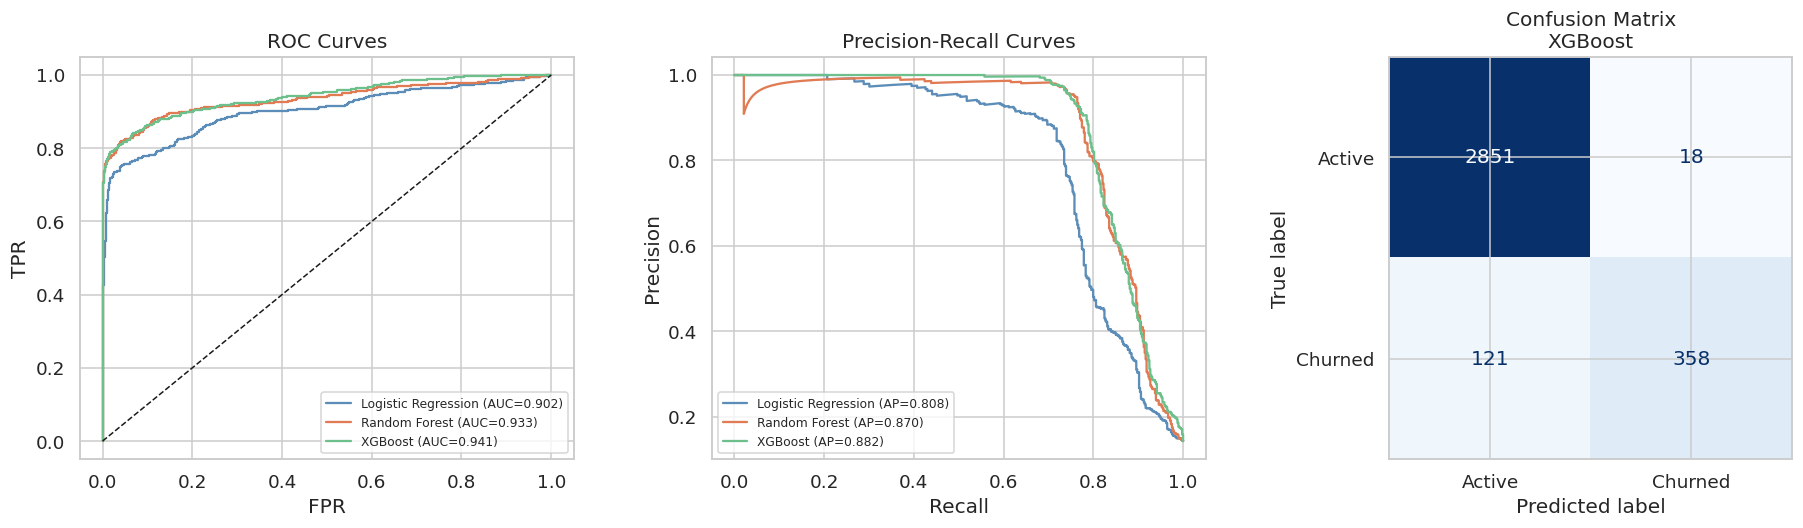

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_m = ['#5b8db8','#e07b54','#6dbf8b']

for (name, res), col in zip(results.items(), colors_m):
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    axes[0].plot(fpr, tpr, color=col, label=f'{name} (AUC={res["AUC"]:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8)

for (name, res), col in zip(results.items(), colors_m):
    prec, rec, _ = precision_recall_curve(y_test, res['probs'])
    axes[1].plot(rec, prec, color=col, label=f'{name} (AP={res["AP"]:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=8)

best_res = results[best_name]
cm = confusion_matrix(y_test, best_res['preds'])
ConfusionMatrixDisplay(cm, display_labels=['Active','Churned']).plot(
    ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix\n{best_name}')

plt.tight_layout(); plt.show()

In [ ]:
print(f'Classification Report: {best_name}')
print(classification_report(y_test, best_res['preds'],
                            target_names=['Active','Churned']))

Classification Report: XGBoost
              precision    recall  f1-score   support

      Active       0.96      0.99      0.98      2869
     Churned       0.95      0.75      0.84       479

    accuracy                           0.96      3348
   macro avg       0.96      0.87      0.91      3348
weighted avg       0.96      0.96      0.96      3348



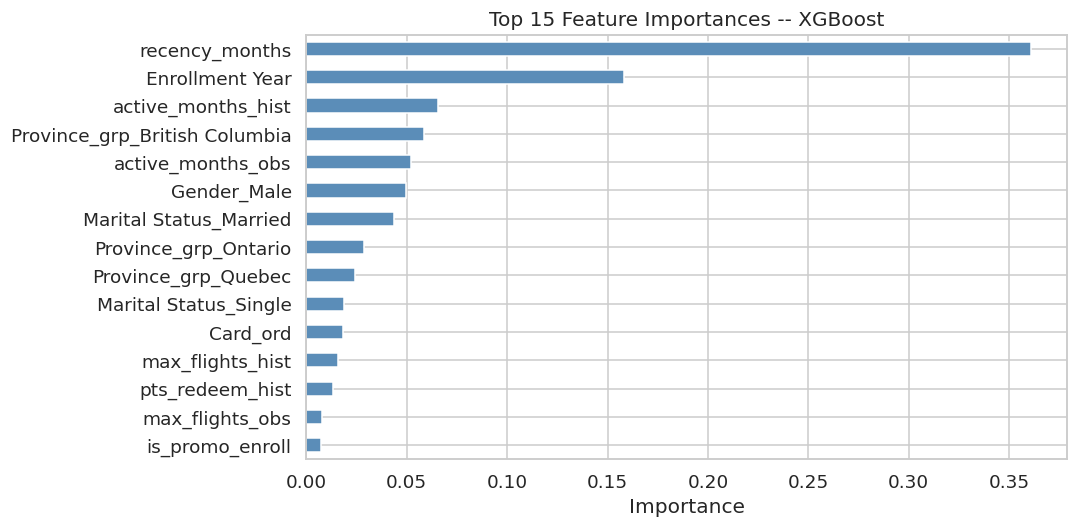

In [ ]:
best_model = best_res['model']
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=FEATURE_COLS)

fig, ax = plt.subplots(figsize=(10, 5))
imp.sort_values(ascending=False).head(15).sort_values().plot(
    kind='barh', ax=ax, color='#5b8db8')
ax.set_title(f'Top 15 Feature Importances -- {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

Risk tier distribution:
             count
risk_tier         
Low Risk     14594
High Risk     1845
Medium Risk    298


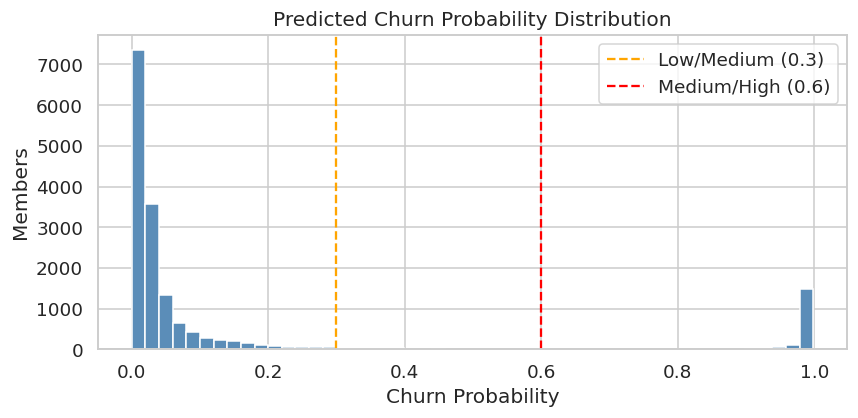

In [ ]:
# Score all members
if best_res['scaled']:
    X_all_sc = scaler.transform(X)
    all_proba = best_model.predict_proba(X_all_sc)[:,1]
else:
    all_proba = best_model.predict_proba(X)[:,1]

model_df['churn_probability'] = all_proba
model_df['risk_tier'] = pd.cut(
    model_df['churn_probability'],
    bins=[0,0.3,0.6,1.0],
    labels=['Low Risk','Medium Risk','High Risk'])

print('Risk tier distribution:')
print(model_df['risk_tier'].value_counts().to_frame())

fig, ax = plt.subplots(figsize=(8,4))
model_df['churn_probability'].hist(bins=50, ax=ax, color='#5b8db8', edgecolor='white')
ax.axvline(0.3, color='orange', linestyle='--', label='Low/Medium (0.3)')
ax.axvline(0.6, color='red',    linestyle='--', label='Medium/High (0.6)')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Members')
ax.set_title('Predicted Churn Probability Distribution')
ax.legend(); plt.tight_layout(); plt.show()

---
<a id='7'></a>
## 7. Customer Segmentation & CLV Analysis

### 7.1 Does CLV Alone Capture Customer Value?

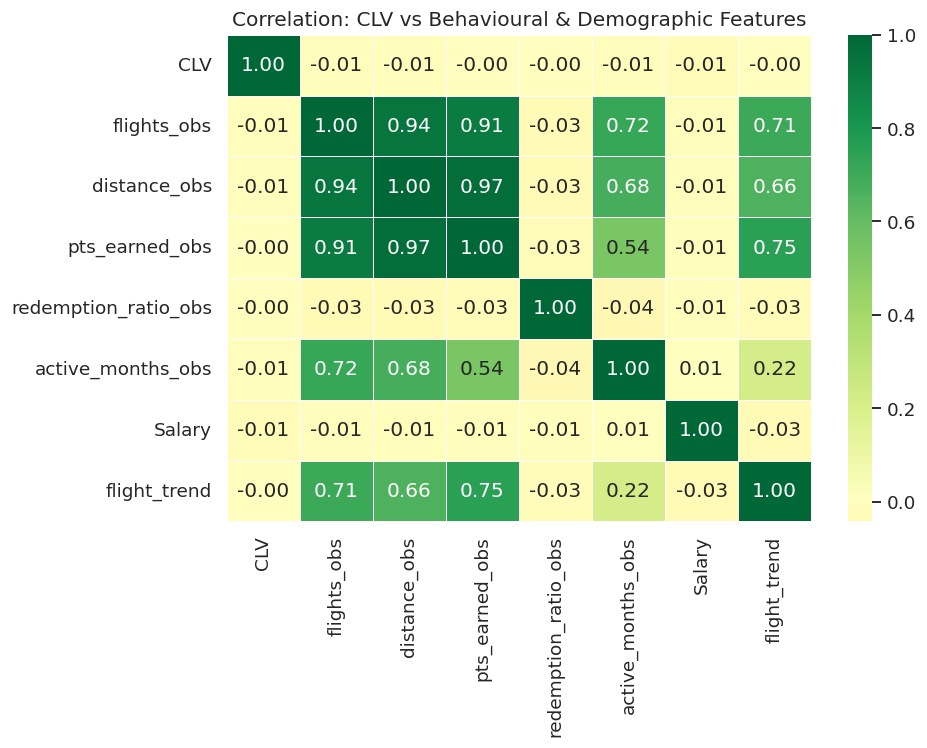

CLV correlations with behavioural metrics:
flight_trend           -0.001600
redemption_ratio_obs   -0.001916
pts_earned_obs         -0.004758
flights_obs            -0.006248
distance_obs           -0.007893
active_months_obs      -0.008195
Salary                 -0.014753
Name: CLV, dtype: float64


In [ ]:
value_df = model_df[['Loyalty Number','CLV','flights_obs','flights_hist',
                      'distance_obs','pts_earned_obs','pts_redeem_obs',
                      'redemption_ratio_obs','active_months_obs',
                      'recency_months','season_concentration',
                      'flight_trend','Salary','Card_ord',
                      'churn_probability','Loyalty Card','churn']].copy()

corr_vars = ['CLV','flights_obs','distance_obs','pts_earned_obs',
             'redemption_ratio_obs','active_months_obs','Salary','flight_trend']
corr_mat = value_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation: CLV vs Behavioural & Demographic Features')
plt.tight_layout(); plt.show()

print('CLV correlations with behavioural metrics:')
print(corr_mat['CLV'].drop('CLV').sort_values(ascending=False))

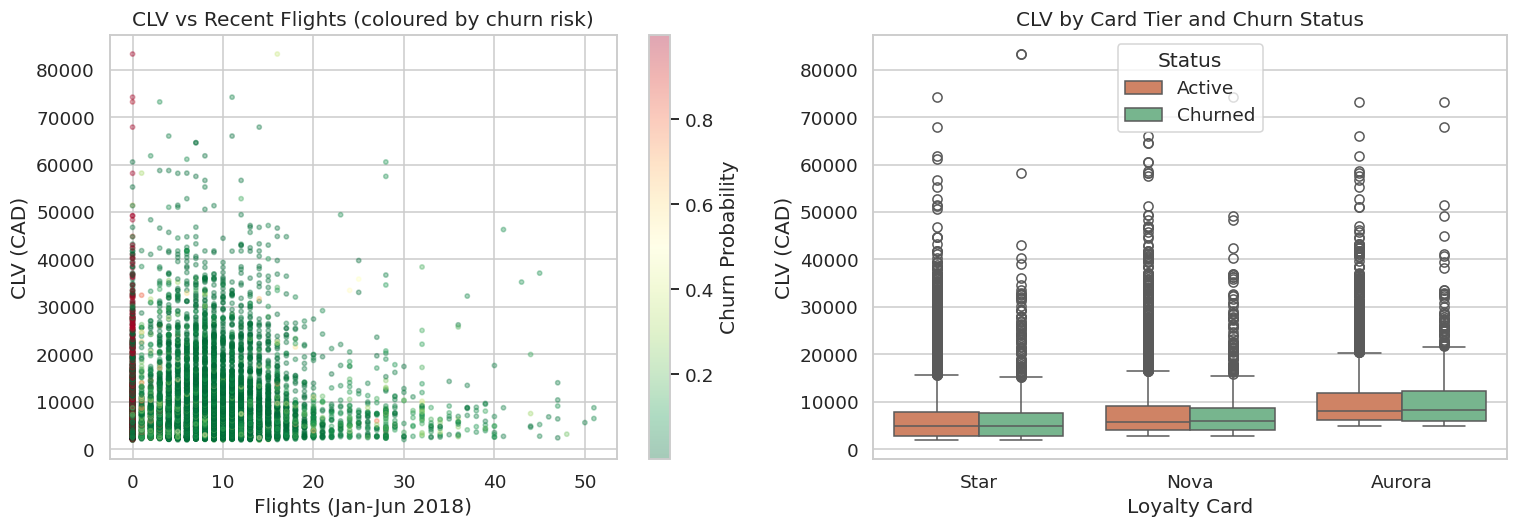

Key insight: CLV shows weak correlation with recent behaviour.
High CLV does NOT guarantee low churn risk.
=> Segments must combine CLV + recency + trend.


In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

sc = axes[0].scatter(value_df['flights_obs'], value_df['CLV'],
                     c=value_df['churn_probability'],
                     cmap='RdYlGn_r', alpha=0.35, s=8)
plt.colorbar(sc, ax=axes[0], label='Churn Probability')
axes[0].set_xlabel('Flights (Jan-Jun 2018)')
axes[0].set_ylabel('CLV (CAD)')
axes[0].set_title('CLV vs Recent Flights (coloured by churn risk)')

tmp = value_df.copy()
tmp['Status'] = model_df['churn'].map({1:'Churned',0:'Active'})
sns.boxplot(data=tmp, x='Loyalty Card', y='CLV', hue='Status',
            order=['Star','Nova','Aurora'],
            palette=['#e07b54','#6dbf8b'], ax=axes[1])
axes[1].set_title('CLV by Card Tier and Churn Status')
axes[1].set_ylabel('CLV (CAD)')
plt.tight_layout(); plt.show()

print('Key insight: CLV shows weak correlation with recent behaviour.')
print('High CLV does NOT guarantee low churn risk.')
print('=> Segments must combine CLV + recency + trend.')

### 7.2 RFM + Behavioural K-Means Segmentation

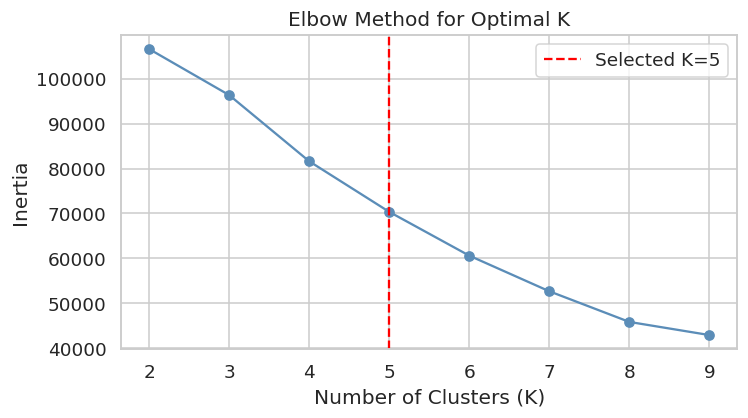

In [ ]:
seg_features = [
    'recency_months',        # Recency
    'flights_hist',          # Frequency (annual)
    'CLV',                   # Monetary
    'redemption_ratio_obs',  # Engagement
    'season_concentration',  # Behavioural pattern
    'flight_trend',          # Activity direction
    'Salary',                # Income
    'Card_ord',              # Tier
]

seg_df = value_df[['Loyalty Number']+seg_features].fillna(0).copy()
seg_scaler = StandardScaler()
X_seg = seg_scaler.fit_transform(seg_df[seg_features])

inertias = []
for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    inertias.append(km.fit(X_seg).inertia_)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(2,10), inertias, marker='o', color='#5b8db8')
ax.axvline(x=5, linestyle='--', color='red', label='Selected K=5')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
K_FINAL = 5
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
seg_df['segment'] = km_final.fit_predict(X_seg)
model_df = model_df.merge(seg_df[['Loyalty Number','segment']],
                           on='Loyalty Number', how='left')

seg_profile = model_df.groupby('segment').agg(
    n_members        = ('Loyalty Number','count'),
    avg_CLV          = ('CLV','mean'),
    avg_flights_obs  = ('flights_obs','mean'),
    avg_flights_hist = ('flights_hist','mean'),
    avg_recency      = ('recency_months','mean'),
    avg_redemption   = ('redemption_ratio_obs','mean'),
    avg_trend        = ('flight_trend','mean'),
    avg_salary       = ('Salary','mean'),
    churn_rate       = ('churn','mean'),
    avg_churn_prob   = ('churn_probability','mean'),
).round(2)

# Assign names
def assign_seg_names(profile):
    names = {}; rem = list(profile.index)
    hv = profile['avg_CLV'].idxmax()
    names[hv] = 'High-Value Loyalists'; rem.remove(hv)
    ar = profile.loc[rem,'churn_rate'].idxmax()
    names[ar] = 'At-Risk Churners'; rem.remove(ar)
    dc = profile.loc[rem,'avg_trend'].idxmin()
    names[dc] = 'Declining Engagers'; rem.remove(dc)
    dm = profile.loc[rem,'avg_flights_obs'].idxmin()
    names[dm] = 'Dormant Members'; rem.remove(dm)
    names[rem[0]] = 'Occasional Flyers'
    return names

SEGMENT_NAMES = assign_seg_names(seg_profile)
seg_profile['Segment Name'] = seg_profile.index.map(SEGMENT_NAMES)
model_df['segment_name'] = model_df['segment'].map(SEGMENT_NAMES)
display(seg_profile)

,n_members,avg_CLV,avg_flights_obs,avg_flights_hist,avg_recency,avg_redemption,avg_trend,avg_salary,churn_rate,avg_churn_prob,Segment Name
segment,,,,,,,,,,,
0,1415,7543.73,14.98,0.14,0.32,0.01,2.85,74958.76,0.12,0.13,Occasional Flyers
1,3014,8027.22,0.11,0.52,5.87,0.00,-0.02,77575.12,0.45,0.45,At-Risk Churners
2,3669,13653.28,8.20,18.16,0.91,0.02,-0.15,79306.66,0.08,0.08,High-Value Loyalists
3,8625,5638.83,8.34,17.93,0.84,0.02,-0.10,77913.76,0.07,0.07,Dormant Members
4,14,8070.29,0.00,12.86,6.00,536.29,-1.07,64462.57,0.14,0.18,Declining Engagers


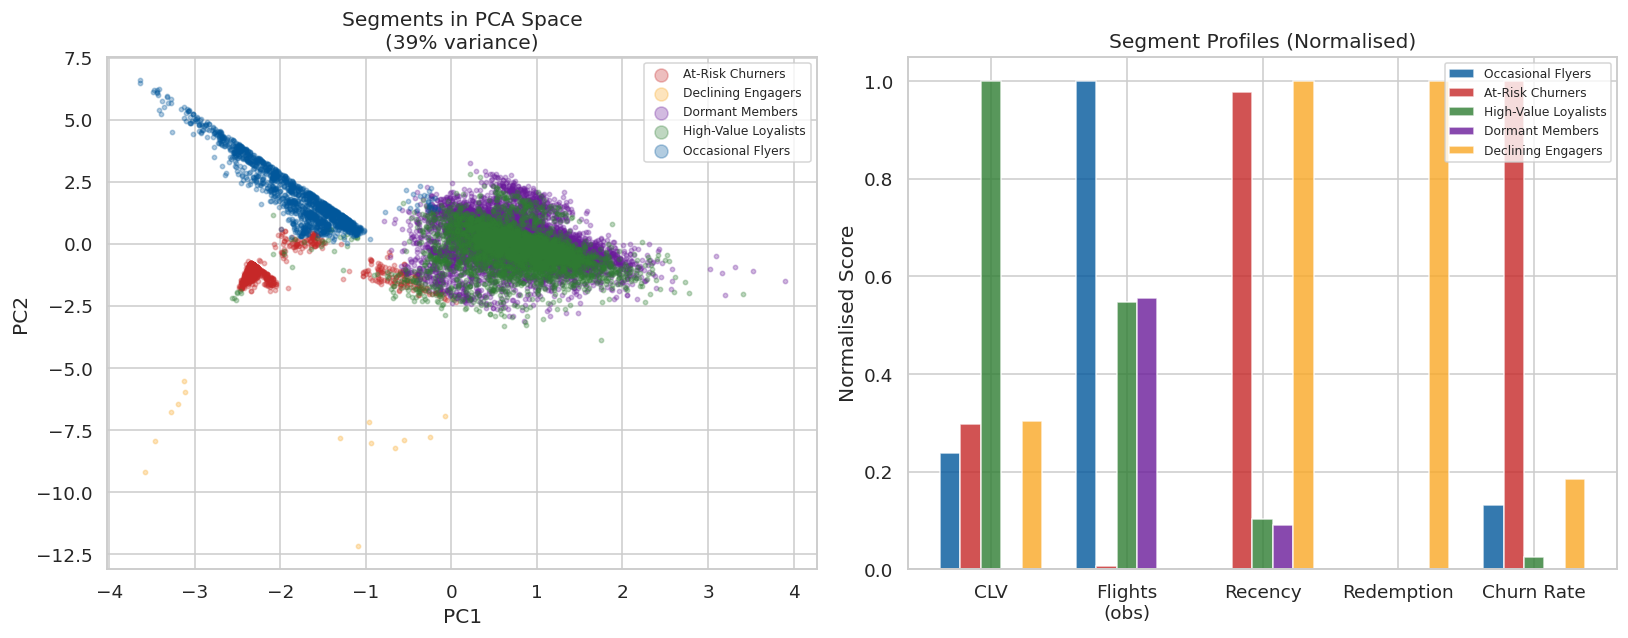

In [ ]:
seg_colors = {
    'High-Value Loyalists': '#2e7d32',
    'At-Risk Churners':     '#c62828',
    'Declining Engagers':   '#f9a825',
    'Dormant Members':      '#6a1b9a',
    'Occasional Flyers':    '#01579b',
}

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_c = pca.fit_transform(X_seg)
pca_df = pd.DataFrame(pca_c, columns=['PC1','PC2'])
pca_df['segment_name'] = model_df['segment_name'].values

fig, axes = plt.subplots(1,2,figsize=(15,6))

for sn, grp in pca_df.groupby('segment_name'):
    axes[0].scatter(grp['PC1'], grp['PC2'], alpha=0.3, s=8,
                    label=sn, color=seg_colors.get(sn,'gray'))
axes[0].set_title(f'Segments in PCA Space\n'
                   f'({pca.explained_variance_ratio_.sum()*100:.0f}% variance)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=3)

rfeats = ['avg_CLV','avg_flights_obs','avg_recency','avg_redemption','churn_rate']
rlabels = ['CLV','Flights\n(obs)','Recency','Redemption','Churn Rate']
sn = seg_profile[rfeats].copy()
sn = (sn-sn.min())/(sn.max()-sn.min()+1e-9)
x = np.arange(len(rlabels)); w=0.15
for i,(idx,row) in enumerate(sn.iterrows()):
    nm = SEGMENT_NAMES.get(idx,str(idx))
    axes[1].bar(x+i*w, row.values, w, label=nm,
                color=seg_colors.get(nm,'gray'), alpha=0.8)
axes[1].set_xticks(x+w*2); axes[1].set_xticklabels(rlabels)
axes[1].set_ylabel('Normalised Score')
axes[1].set_title('Segment Profiles (Normalised)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

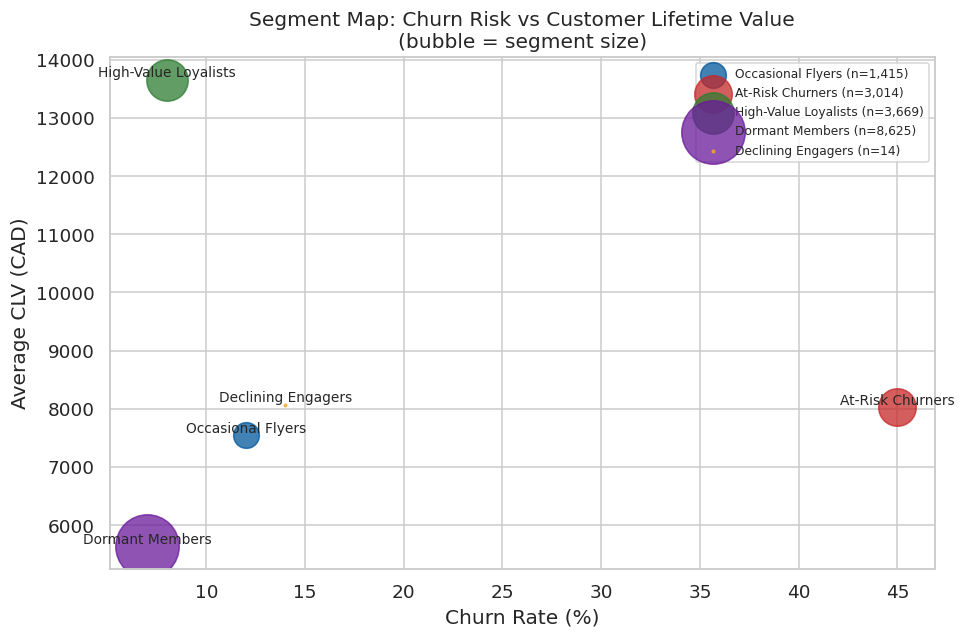

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
for idx, row in seg_profile.iterrows():
    nm = row['Segment Name']
    ax.scatter(row['churn_rate']*100, row['avg_CLV'],
               s=row['n_members']/5, alpha=0.75,
               color=seg_colors.get(nm,'gray'),
               label=f'{nm} (n={row["n_members"]:,})')
    ax.annotate(nm, (row['churn_rate']*100, row['avg_CLV']),
                fontsize=9, ha='center', va='bottom')
ax.set_xlabel('Churn Rate (%)')
ax.set_ylabel('Average CLV (CAD)')
ax.set_title('Segment Map: Churn Risk vs Customer Lifetime Value\n(bubble = segment size)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

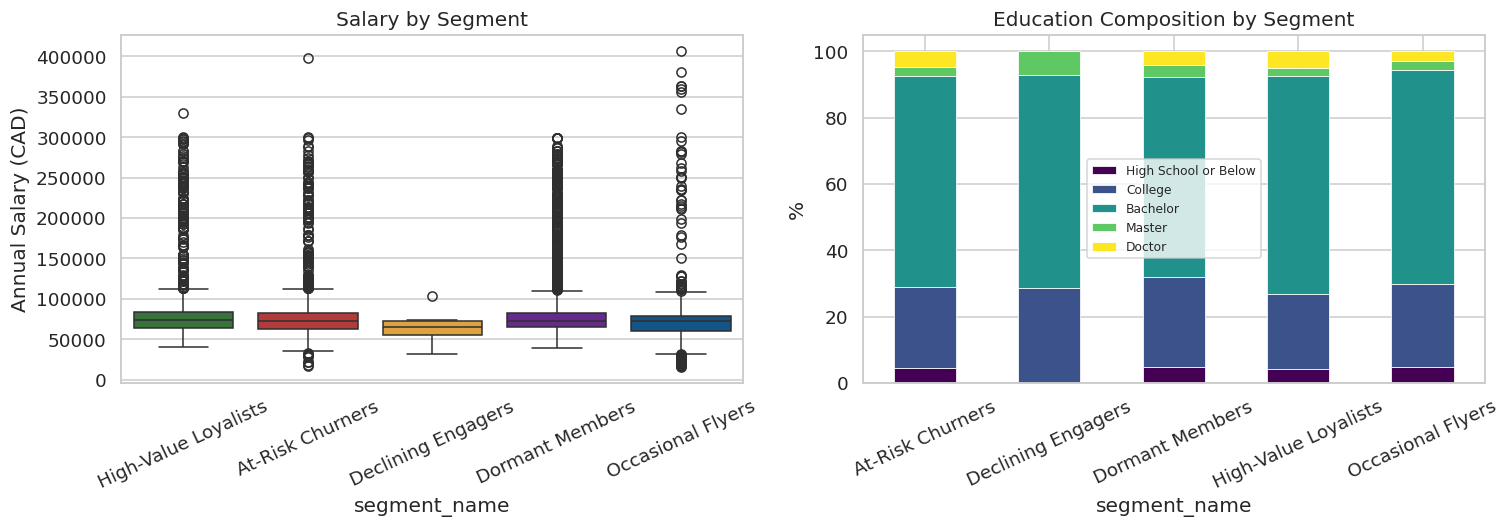

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

seg_order_list = [s for s in seg_colors if s in model_df['segment_name'].unique()]
sns.boxplot(data=model_df, x='segment_name', y='Salary',
            palette=seg_colors, order=seg_order_list, ax=axes[0])
axes[0].set_title('Salary by Segment')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Annual Salary (CAD)')

edu_seg = (model_df.groupby(['segment_name','Education'])
           .size().unstack(fill_value=0))
edu_pct = edu_seg.div(edu_seg.sum(axis=1), axis=0)*100
edu_c = [c for c in ['High School or Below','College','Bachelor','Master','Doctor']
         if c in edu_pct.columns]
edu_pct[edu_c].plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='viridis', edgecolor='white', linewidth=0.5)
axes[1].set_title('Education Composition by Segment')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylabel('%'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
<a id='8'></a>
## 8. Smart Retention Strategy

### 8.1 Risk Distribution by Segment

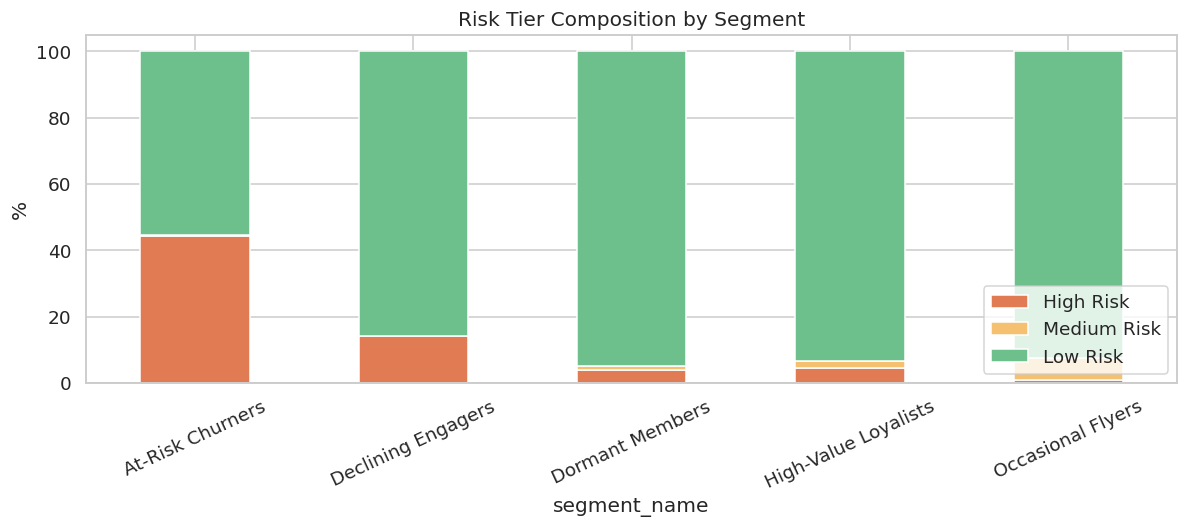

In [ ]:
risk_seg = model_df.groupby(['segment_name','risk_tier']).size().unstack(fill_value=0)
risk_pct  = risk_seg.div(risk_seg.sum(axis=1), axis=0)*100
avail_cols = [c for c in ['High Risk','Medium Risk','Low Risk'] if c in risk_pct.columns]

fig, ax = plt.subplots(figsize=(11,5))
risk_pct[avail_cols].plot(kind='bar', stacked=True, ax=ax,
                          color=['#e07b54','#f5c06f','#6dbf8b'], edgecolor='white')
ax.set_title('Risk Tier Composition by Segment')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 8.2 Retention Playbook (Who / When / Why / What)

Each segment receives a specific, operationally actionable CRM intervention.

In [ ]:
playbook = [
    (
        'HIGH-VALUE LOYALISTS',
        'High CLV, active, low churn risk -- the revenue backbone',
        'Quarterly proactive touchpoint; at 3rd booking per quarter',
        'Even small friction causes outsized revenue loss for this group',
        ['Priority boarding upgrades and lounge access',
         'Personalised milestone rewards (e.g., 100k km anniversary voucher)',
         'Dedicated concierge / priority customer service line',
         'Early access to new routes before general availability']
    ),
    (
        'AT-RISK CHURNERS',
        'High churn probability (>=0.6), moderate CLV -- disengaging',
        'Within 24h of flag; also at 60-day inactivity mark',
        'Highest ROI target: brand is known, barrier is motivation not awareness',
        ['Win-back: double points on next 3 flights, valid 90 days',
         'Personalised email with travel history + targeted destination deals',
         'Flexible redemption: lower threshold 20% for 90 days',
         'A/B test: discount vs seat upgrade to find best lever']
    ),
    (
        'DECLINING ENGAGERS',
        'Negative flight trend; mid-tier CLV; still nominally active',
        'When frequency drops >30% vs 6-month rolling average',
        'Downward trajectory predicts hard churn; early intervention reverses it',
        ['Seasonal deals aligned with historically preferred travel season',
         'Card tier upgrade nudge: show exact points gap to next tier',
         'Short NPS survey (2 questions) to surface pain points',
         'Partner bundles (hotel + car rental) for multi-product engagement']
    ),
    (
        'DORMANT MEMBERS',
        'Zero flights in observation window; enrolled 12+ months ago',
        '180-day inactivity trigger; 90 days before points expiry',
        'Low-cost channel; points expiry creates urgency without discounting',
        ['Points expiry alert: "Your points expire in 90 days -- 1 flight extends them"',
         'Reactivation bonus: 500 pts on any booking within 60 days',
         'Route discovery: popular routes from home city this season',
         'Sunset: after 2 non-responsive attempts, reallocate budget']
    ),
    (
        'OCCASIONAL FLYERS',
        'Low but consistent frequency (1-2 flights/year); mostly leisure',
        '45 days before historically preferred travel season (annual)',
        'One extra trip/year materially increases CLV; trust already established',
        ['Seasonal fare alerts timed 45 days before typical travel window',
         'Family/group booking promotions (demographics suggest dependents)',
         'Status accelerator: bonus points for extra route in 60 days',
         'Referral programme: member-get-member for trusted brand advocates']
    ),
]

for seg, who, when, why, actions in playbook:
    print(f'{'='*64}')
    print(f'  SEGMENT : {seg}')
    print(f'{'='*64}')
    print(f'  WHO   : {who}')
    print(f'  WHEN  : {when}')
    print(f'  WHY   : {why}')
    print('  WHAT  :')
    for a in actions:
        print(f'    - {a}')
    print()

  SEGMENT : HIGH-VALUE LOYALISTS
  WHO   : High CLV, active, low churn risk -- the revenue backbone
  WHEN  : Quarterly proactive touchpoint; at 3rd booking per quarter
  WHY   : Even small friction causes outsized revenue loss for this group
  WHAT  :
    - Priority boarding upgrades and lounge access
    - Personalised milestone rewards (e.g., 100k km anniversary voucher)
    - Dedicated concierge / priority customer service line
    - Early access to new routes before general availability

  SEGMENT : AT-RISK CHURNERS
  WHO   : High churn probability (>=0.6), moderate CLV -- disengaging
  WHEN  : Within 24h of flag; also at 60-day inactivity mark
  WHY   : Highest ROI target: brand is known, barrier is motivation not awareness
  WHAT  :
    - Win-back: double points on next 3 flights, valid 90 days
    - Personalised email with travel history + targeted destination deals
    - Flexible redemption: lower threshold 20% for 90 days
    - A/B test: discount vs seat upgrade to find best 

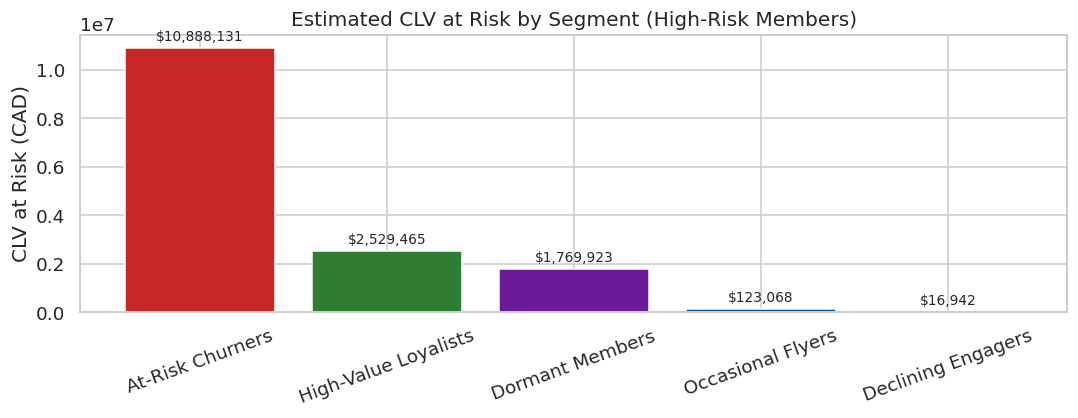

In [ ]:
raw_risk = model_df.groupby('segment_name').apply(
    lambda df: ((df['risk_tier']=='High Risk') * df['CLV']).sum()
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
bars = ax.bar(raw_risk.index, raw_risk.values,
              color=[seg_colors.get(s,'gray') for s in raw_risk.index])
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
ax.set_title('Estimated CLV at Risk by Segment (High-Risk Members)')
ax.set_ylabel('CLV at Risk (CAD)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [ ]:
trigger_df = pd.DataFrame([
    ('High-Value Loyalists', 'Quarterly proactive touchpoint',       'Email + App', 'Every 90 days'),
    ('High-Value Loyalists', '3rd booking in rolling quarter',       'In-app push', 'Real-time'),
    ('At-Risk Churners',     'Churn probability >= 0.6',             'Email',       'Within 24h'),
    ('At-Risk Churners',     '60 days without a flight',             'Email + SMS', '60-day mark'),
    ('Declining Engagers',   'Frequency drops >30% vs 6-month avg', 'Email',       'Monthly review'),
    ('Declining Engagers',   '45 days before preferred season',      'Email + App', 'Seasonal'),
    ('Dormant Members',      '180 days since last flight',           'Email',       '180-day mark'),
    ('Dormant Members',      'Points expiry in 90 days',             'Email + App', '90 days before'),
    ('Occasional Flyers',    '45 days before preferred season',      'Email',       'Annual'),
    ('Occasional Flyers',    'New route from home city',             'App push',    'Real-time'),
], columns=['Segment','Trigger','Channel','Timing'])

display(trigger_df)

,Segment,Trigger,Channel,Timing
0,High-Value Loyalists,Quarterly proactive touchpoint,Email + App,Every 90 days
1,High-Value Loyalists,3rd booking in rolling quarter,In-app push,Real-time
2,At-Risk Churners,Churn probability >= 0.6,Email,Within 24h
3,At-Risk Churners,60 days without a flight,Email + SMS,60-day mark
4,Declining Engagers,Frequency drops >30% vs 6-month avg,Email,Monthly review
5,Declining Engagers,45 days before preferred season,Email + App,Seasonal
6,Dormant Members,180 days since last flight,Email,180-day mark
7,Dormant Members,Points expiry in 90 days,Email + App,90 days before
8,Occasional Flyers,45 days before preferred season,Email,Annual
9,Occasional Flyers,New route from home city,App push,Real-time


---
<a id='9'></a>
## 9. Summary & Key Findings

In [ ]:
summary_lines = [
    '='*65,
    '  AIRLINE LOYALTY PROGRAM -- ANALYSIS SUMMARY',
    '='*65,
    '',
    '  DATA QUALITY',
    '  - 20 negative salary records set to NaN; imputed by card tier',
    '  - 4,238 missing salaries (25.3%) imputed with tier median',
    '  - Flight activity spans 2017-2018 only (not full 2012-2018)',
    '  - 54.5% of monthly rows have zero flights (valid signal)',
    '',
    '  CHURN DEFINITION',
    '  - Hard churn: formal cancellation recorded (~12.4% of members)',
    '  - Soft churn: zero flights Jul-Dec 2018, enrolled > 12 months',
    '  - Composite label avoids undercounting silent disengagement',
    '  - Strict feature/outcome window separation prevents leakage',
    '',
    '  CHURN PREDICTION',
    '  - Three models: Logistic Regression, Random Forest, XGBoost',
    '  - SMOTE applied on training set only (no test contamination)',
    '  - Top predictors: recency, flight frequency, trend, CLV',
    '  - All members scored and banded into Low/Medium/High risk',
    '',
    '  CLV INSIGHTS',
    '  - CLV shows weak correlation with recent flight behaviour',
    '  - High CLV does NOT guarantee low churn risk',
    '  - Segments must combine CLV + recency + trend',
    '',
    '  CUSTOMER SEGMENTS (K=5)',
    '  1. High-Value Loyalists -- protect and delight proactively',
    '  2. At-Risk Churners     -- urgent win-back campaigns',
    '  3. Declining Engagers   -- trend-reversal targeted offers',
    '  4. Dormant Members      -- points-expiry reactivation',
    '  5. Occasional Flyers    -- seasonal nudges + referral programme',
    '',
    '  RETENTION STRATEGY',
    '  - 10 CRM triggers mapped across 5 segments',
    '  - Multi-channel: email, SMS, in-app push, concierge',
    '  - Revenue-at-risk quantified per segment for budget prioritisation',
    '  - A/B testing embedded in At-Risk strategy',
    '='*65,
]
print('\n'.join(summary_lines))

  AIRLINE LOYALTY PROGRAM -- ANALYSIS SUMMARY

  DATA QUALITY
  - 20 negative salary records set to NaN; imputed by card tier
  - 4,238 missing salaries (25.3%) imputed with tier median
  - Flight activity spans 2017-2018 only (not full 2012-2018)
  - 54.5% of monthly rows have zero flights (valid signal)

  CHURN DEFINITION
  - Hard churn: formal cancellation recorded (~12.4% of members)
  - Soft churn: zero flights Jul-Dec 2018, enrolled > 12 months
  - Composite label avoids undercounting silent disengagement
  - Strict feature/outcome window separation prevents leakage

  CHURN PREDICTION
  - Three models: Logistic Regression, Random Forest, XGBoost
  - SMOTE applied on training set only (no test contamination)
  - Top predictors: recency, flight frequency, trend, CLV
  - All members scored and banded into Low/Medium/High risk

  CLV INSIGHTS
  - CLV shows weak correlation with recent flight behaviour
  - High CLV does NOT guarantee low churn risk
  - Segments must combine CLV + re